# SI 305 Winter 2026 Problem Set 2

# 1	Characterizing the EBLL data

## 1.1	Load and characterize the dataset

In [2]:
#Import needed packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Load dataset
ebll_data = pd.read_csv('https://drive.google.com/uc?export=download&confirm=1&export=download&id=1Gn3H_23xwSJRXXzaLUmP_gDGxwu0eP5W')
#Find row and column count using .shape
print(ebll_data.shape)
#Find which column has the fewest amount of missing values
print(ebll_data.isna().sum())
#Find columns represented with float64
print(ebll_data.dtypes.value_counts())

(30800, 8)
Geographic Area(s)                             0
Year(s)                                        0
Age Group/Status                               0
Test Type                                      0
Blood Lead Reference Value                     0
Number of Children Tested                   4878
Number of Children with an EBLL            12376
Percent of Children Tested with an EBLL        0
dtype: int64
object     4
float64    3
int64      1
Name: count, dtype: int64


1. How many rows and columns does the dataset contain?

The dataset contains 30,800 rows and 8 columns

2. Which column has the fewest non-null values?

The number of children with an EBLL has the fewest non-null values, with 12,376.

3. How many columns are represented using the float64 data type?

There are 3 columns represented with the float64 datatype.

## 1.2	Clean the Data

In [5]:
#Remove all rows in which there is a null value for the number of children tested
ebll_clean = ebll_data.dropna(subset = ['Number of Children Tested'])
#Remove rows with BLRV < or > 3.5
ebll_clean = ebll_clean.loc[ebll_clean['Blood Lead Reference Value'] == 3.5]
#Remove all asterisks from zip code
ebll_clean['Geographic Area(s)'] = ebll_clean['Geographic Area(s)'].str.replace(r'\*', '', regex = True).astype(float)
#Create new 'Suppressed' column 
ebll_clean['Suppressed'] = (ebll_clean['Percent of Children Tested with an EBLL'] == 'Suppressed')
#Replace 'Suppressed' with NaN in Percent of Children Tested column
ebll_clean['Percent of Children Tested with an EBLL'] = ebll_clean['Percent of Children Tested with an EBLL'].replace('Suppressed', np.nan)

In [6]:
#Find how many rows are in the new dataset
print(ebll_clean.shape)
#Find how many reports are unsuppressed
print(ebll_clean['Suppressed'].value_counts())
#Find percent of reports in the cleaned dataset that are unsuppressed
unsuppressed_rows = (ebll_clean['Suppressed'] != True).sum()
print(unsuppressed_rows/len(ebll_clean) * 100)

(12961, 9)
Suppressed
False    6558
True     6403
Name: count, dtype: int64
50.59794768922151


1. How many rows are in the cleaned dataset?

There are 12,961 rows in the cleaned dataset.

2. How many reports in the cleaned dataset are unsuppressed?

There are 6,558 reports in the dataset that are unsuppressed.

3. What percent of reports in the clean dataset are unsupressed?

Approximately 50.6% of reports are unsuppressed.


## 1.3	Characterize Suppressed Reports

In [5]:
#Find percentage of zip codes that have more than 50% of reports suppressed
suppressed_totals = ebll_clean.groupby('Geographic Area(s)')['Suppressed'].mean()
suppressed_over50 = (suppressed_totals > 0.5).mean()
print(suppressed_over50)
#Find percent of zip codes that have less than 25% of their reports suppressed
suppressed_under25 = (suppressed_totals < 0.25).mean()
print(suppressed_under25)
#Find year with highest percent of reports suppressed
yearly_totals = ebll_clean.groupby('Year(s)')['Suppressed'].mean()
print(yearly_totals.idxmax(), yearly_totals.max())

0.5411167512690356
0.21725888324873097
2023 0.5321100917431193


1. What percent of zip codes have more than 50 percent of their reports suppressed?

Approximately 54.1 percent of zip codes have more than 50 percent of their reports suppressed

2. What percent of zip codes have less than 25% of their reports suppressed?

Approximately 21.7 percent of zip codes have less than 25 percent of their reports suppressed.

3. Which year has the highest percent of reports that are suppressed? What percent of reports in that year are suppressed?

2023 has the highest percentage of suppressed reports, with approximately 53.2 percent of reports being suppressed.

## 1.4 Plotting Suppressed Reports

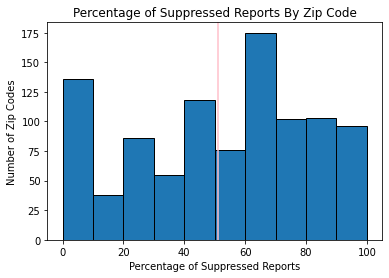

In [20]:
#Create a histogram that plots the percent of suppressed reports in each zip code
zip_code_percentage = ebll_clean.groupby('Geographic Area(s)')['Suppressed'].mean()
#Claude AI: How can I make bins divided evenly from 10% to 100%? Told me to use range = (x,y)
plt.hist(zip_code_percentage * 100, bins=10, range=(0,100), edgecolor='black')
plt.axvline(zip_code_percentage.mean() * 100, color = 'pink')
plt.title('Percentage of Suppressed Reports By Zip Code')
plt.xlabel('Percentage of Suppressed Reports')
plt.ylabel('Number of Zip Codes')
plt.show()

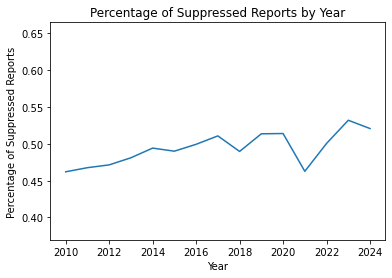

In [28]:
#Create a line plot that shows the percent os suppressed reports across years 
yearly_totals_percent = yearly_totals * 100
plt.plot(yearly_totals.index, yearly_totals)
plt.xlabel('Year')
plt.ylabel('Percentage of Suppressed Reports')
plt.title('Percentage of Suppressed Reports by Year')
plt.ylim(0.8 * (yearly_totals.min()), 1.25 * (yearly_totals.max()))
plt.show()

1. Briefly describe what you observe based on these plots.

These two plots show several interesting trend. First, the histogram shows that the most common percentage of suppressed reports is around 60 to 70 percent, with approximately 170 zip codes having this percentage of suppressed reports. This implies that it is rather common for a zip code to have over half of its reports suppressed. Along with this, the second greatest histogram bin is around 0 to 10 percent, implying that there is also a rather high amount of zip codes with little to no suppressed reports. Although promising at first, I suspect that this comes from zip codes with a small number of projects, which happen to be unsupressed. Second, the line chart shows that the amount of suppressed reports is steadily increasing over time, as the percentage was around 47 in 2010, compared to approximately 51 in 2024. Although there was a minor dip in 2021, The chart still shows steady rise, implying that suppressed reports may be becoming more common.


# Comparing Across Different Parts of Michigan

## 2.1 Load and Characterize the Zip Code Data

In [7]:
#Load the CSV file
zip_county_data = pd.read_csv('https://drive.google.com/uc?export=download&confirm=1&export=download&id=11MVV81Z48cgnc_ZsHAtdk7JYsRAZzNMq')
#Create new dataframe that inlcudes only Michigan zip codes
zip_mi = zip_county_data[zip_county_data['STATE'] == 'MI']
zip_mi.head
#Drop STCOUNTYFP and CLASSFP columns
zip_mi = zip_mi.drop(columns = ['STCOUNTYFP', 'CLASSFP'])
zip_mi.head(n=30)

,ZIP,COUNTYNAME,STATE
21425,48738,Alcona County,MI
21426,48762,Alcona County,MI
21427,48750,Alcona County,MI
21428,48721,Alcona County,MI
21429,48728,Alcona County,MI
21430,48740,Alcona County,MI
21431,48745,Alcona County,MI
21432,48705,Alcona County,MI
21433,48761,Alcona County,MI
21434,48737,Alcona County,MI


In [8]:
#Find how many zip codes span multiple counties
#Match zip codes to counties
county_count = zip_mi.groupby('ZIP')['COUNTYNAME'].nunique()
print(county_count.shape)
#Find zip code with more than 1 county connected
more_than_one = county_count[county_count > 1]
more_than_one_count = len(more_than_one)
print(more_than_one_count)
print(more_than_one_count / len(county_count))

(1102,)
362
0.32849364791288566


1. How many rows and columns does this new dataframe contain?
    
    This dataframe contains 1,102 rows (zip codes) and 3 columns.
    
2. How many zip codes in Michigan span multiple counties? What percent of zip codes is this

    326 Michigan zip codes span multiple counties, approximately 32.8 percent of all zip codes.

## 2.2 Merge The Datasets

In [10]:
#Merge the datasets
#Convert ebll_clean zip codes to int
ebll_clean['Geographic Area(s)'] = ebll_clean['Geographic Area(s)'].astype(int)
#Merging
ebll_county_data = pd.merge(ebll_clean, zip_mi, left_on = 'Geographic Area(s)', right_on = 'ZIP')
#Drop null values from county names
ebll_county_data = ebll_county_data.dropna(subset = ['COUNTYNAME'])
ebll_county_data.head(n=20)
ebll_county_data.shape

(19592, 12)

In [67]:
ebll_county_data.head(n=30)

,Geographic Area(s),Year(s),Age Group/Status,Test Type,Blood Lead Reference Value,Number of Children Tested,Number of Children with an EBLL,Percent of Children Tested with an EBLL,Suppressed,ZIP,COUNTYNAME,STATE
0,48001,2010,All Children <6,All Test Types,3.5,150.0,15.0,10,False,48001,St. Clair County,MI
1,48001,2011,All Children <6,All Test Types,3.5,156.0,7.0,4.5,False,48001,St. Clair County,MI
2,48001,2012,All Children <6,All Test Types,3.5,167.0,12.0,7.2,False,48001,St. Clair County,MI
3,48001,2013,All Children <6,All Test Types,3.5,168.0,11.0,6.5,False,48001,St. Clair County,MI
4,48001,2014,All Children <6,All Test Types,3.5,144.0,NaN,NaN,True,48001,St. Clair County,MI
5,48001,2015,All Children <6,All Test Types,3.5,144.0,9.0,6.3,False,48001,St. Clair County,MI
6,48001,2016,All Children <6,All Test Types,3.5,178.0,14.0,7.9,False,48001,St. Clair County,MI
7,48001,2017,All Children <6,All Test Types,3.5,176.0,NaN,NaN,True,48001,St. Clair County,MI
8,48001,2018,All Children <6,All Test Types,3.5,132.0,NaN,NaN,True,48001,St. Clair County,MI
9,48001,2019,All Children <6,All Test Types,3.5,155.0,NaN,NaN,True,48001,St. Clair County,MI


1. How many rows are in this dataset?

There are 19,592 rows in this new dataset

## 2.3 Aggregate by County

In [11]:
#Find suppressed report percentage for Ingham, Washtenaw, and Wayne counties
county_percentage = ebll_county_data.groupby('COUNTYNAME')['Suppressed'].mean()
ingham_percent = county_percentage.loc['Ingham County']
washtenaw_percent = county_percentage.loc['Washtenaw County']
wayne_percent = county_percentage.loc['Wayne County']
print(ingham_percent * 100 , washtenaw_percent * 100, wayne_percent * 100)

38.940809968847354 55.52884615384615 17.86389413988658


In [13]:
#Find percentage of reports where more than 5% of children had an EBLL
#Convert children test percentage to int
ebll_county_data['Percent of Children Tested with an EBLL'] = ebll_county_data['Percent of Children Tested with an EBLL'].astype(float)
ebll_percent = ebll_county_data.groupby('COUNTYNAME')['Percent of Children Tested with an EBLL'].value_counts()
unsuppressed_data = ebll_county_data[ebll_county_data['Suppressed'] == False]
county_over_five_mean = unsuppressed_data.groupby('COUNTYNAME')['Percent of Children Tested with an EBLL'].apply(lambda x: (x > 5.0).mean())
ingham_over_five = county_over_five_mean.loc['Ingham County']
washtenaw_over_five = county_over_five_mean.loc['Washtenaw County']
wayne_over_five = county_over_five_mean.loc['Wayne County']
print(ingham_over_five * 100, washtenaw_over_five * 100, wayne_over_five * 100)

57.14285714285714 17.2972972972973 51.093210586881476


1. For each of the three counties, what percent of reports are suppressed?

Ingham County - approximately 38.9 percent of reports are suppressed
Washtenaw County - approximately 55.5 percent of reports are suppressed
Wayne County - approximately 17.9 percent of reports are suppressed

2. For Each county, among unsuppressed reports, what percent of reports show that more than 5 percent of children had an EBLL?

Ingham County - approximately 57.1 percent of reports show that more than 5 percent of children had an EBLL
Washtenaw County - approximately 17.3 percent of reports show that more than 5 percent of children had an EBLL
Wayne County - pproximately 51.1 percent of reports show that more than 5 percent of children had an EBLL

## 2.4 Analyze Trends Over Time

In [22]:
#Calculate the positive tests by county by year
#Filter to the 3 counties in question
counties = unsuppressed_data[unsuppressed_data['COUNTYNAME'].isin(['Ingham County', 'Washtenaw County', 'Wayne County'])]
#Groupby county and year and use aggregations (derived from section 5)
annual = counties.groupby(['COUNTYNAME', 'Year(s)']).aggregate(
    total_tested = pd.NamedAgg(column='Number of Children Tested', aggfunc='sum'),
    total_affected = pd.NamedAgg(column='Number of Children with an EBLL', aggfunc='sum')
).reset_index()
annual['percentage_affected'] = (annual['total_affected'] / annual['total_tested']) * 100

In [23]:
#Find exact data for 2024
results_in_2024 = annual[annual['Year(s)'] == 2024]
print(results_in_2024[['COUNTYNAME', 'percentage_affected']])

          COUNTYNAME  percentage_affected
14     Ingham County             5.583148
29  Washtenaw County             2.595156
44      Wayne County             5.932902


1. In 2024, what percent of children tested in each county had an EBLL?

Ingham County - approximately 5.6 percent of children tested had an EBLL.
Washtenaw County - approximately 2.6 percent of children tested had an EBLL.
Wayne County - approximately 5.9 percent of children tested had an EBLL.

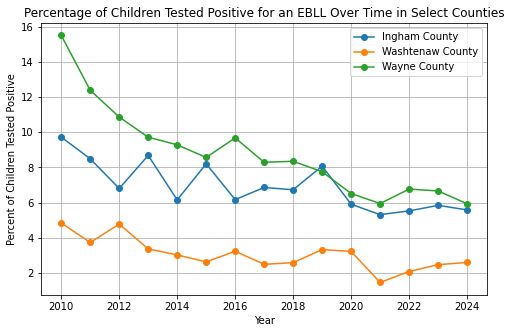

In [30]:
#Create a line plot that shows the percent of tested children with an EBLL in each county over time
fig, ax = plt.subplots(figsize=(8, 5))
#Loop creating a line for each county
for county in ['Ingham County', 'Washtenaw County', 'Wayne County']:
    county_data = annual[annual['COUNTYNAME'] == county]
    ax.plot(county_data['Year(s)'], county_data['percentage_affected'], label=county, marker='o')
ax.set_title('Percentage of Children Tested Positive for an EBLL Over Time in Select Counties')
ax.set_xlabel('Year')
ax.set_ylabel('Percent of Children Tested Positive')
ax.grid(True)
ax.legend()
plt.show()

Based on the plot, it appears that the percentage of children tested positive for an EBLL is decreasing in all three of the counties in question. That being said, there are still some interesting trends. First, Ingham and Wayne counties both had about a 6% positive rate compared to Washtenaw's 2.5%. I hypothesize that this is caused by a greater number of low income communities in Ingham and Wayne counties, which means older homes and less resources for lead abatement treatment. Second, Washtenaw county has seen a slight increase in EBLL cases since 2021, going from about 1% to about 2.5%. While this is a small amount, it is concerning that the number is rising at all.